# TP : Détection de fraude bancaire par arbres de décision

## Objectif
L'objectif est de développer un modèle d'arbre de décision qui prédit si une transaction par carte de crédit est frauduleuse ou légitime, afin de protéger les clients et de réduire les pertes financières.

## Description des données

| Colonne | Description |
|---------|-------------|
| `Transaction_ID` | Identifiant unique de la transaction |
| `User_ID` | Identifiant de l'utilisateur |
| `Transaction_Amount` | Montant de la transaction (€) |
| `Transaction_Type` | Type : ATM Withdrawal, Online Purchase, POS Payment, etc. |
| `Time_of_Transaction` | Heure de la transaction (0–23) |
| `Device_Used` | Appareil utilisé : Mobile, Desktop, Tablet |
| `Location` | Ville de la transaction |
| `Previous_Fraudulent_Transactions` | Nombre de fraudes passées de l'utilisateur |
| `Account_Age` | Ancienneté du compte (en mois) |
| `Number_of_Transactions_Last_24H` | Nombre de transactions dans les dernières 24h |
| `Payment_Method` | Méthode : Credit Card, Debit Card, UPI, Net Banking |
| `Fraudulent` | **Variable cible** : 0 = légitime, 1 = fraude |

# Phase 0 - Imports

### Import des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)



## Phase 1 — Business Understanding

### Contexte
Je travaille en tant que Data scientist

### Objectif
Développer un modèle d'arbre de décision capable de détecter les transactions frauduleuses à partir des caractéristiques de chaque opération bancaire.

### Questions métier à résoudre

1. Peut-on prédire de manière fiable qu'une transaction est frauduleuse ?
2. Quelles sont les caractéristiques les plus discriminantes entre fraude et transaction légitime ?
3. Le modèle peut-il réduire significativement les fraudes non détectées ?

## Phase 2 — Data Understanding

### 2.1 Chargement des données

In [2]:
df=pd.read_csv('Fraud Detection Dataset.csv')

### 2.2 Exploration initiale

In [3]:
#Copie du DataFrame 
data = df.copy()
#Affichage des premières lignes du DataFrame
data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.7600,ATM Withdrawal,16.0000,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.5800,ATM Withdrawal,13.0000,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.0200,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.1000,Bill Payment,15.0000,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.5000,POS Payment,19.0000,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
#Dimension du dataset
print('Dimension du datastet:',df.shape[0],'lignes et',df.shape[1],'colonnes')
#Affichage des types de données
print('\nTypes de données:')
print(df.dtypes)

Dimension du datastet: 51000 lignes et 12 colonnes

Types de données:
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object


## 2.3 Distribution de la variable cible

In [5]:
#Calcul du nombre et du pourcentage d'echantillons pour chaque classe
counts = df['Fraudulent'].value_counts()
pcts = df['Fraudulent'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Nombre': counts, 'Pourcentage (%)': pcts.round(4)})
summary.index = ['Legitime (0)', 'Fraude (1)']
print(summary)

              Nombre  Pourcentage (%)
Legitime (0)   48490          95.0784
Fraude (1)      2510           4.9216


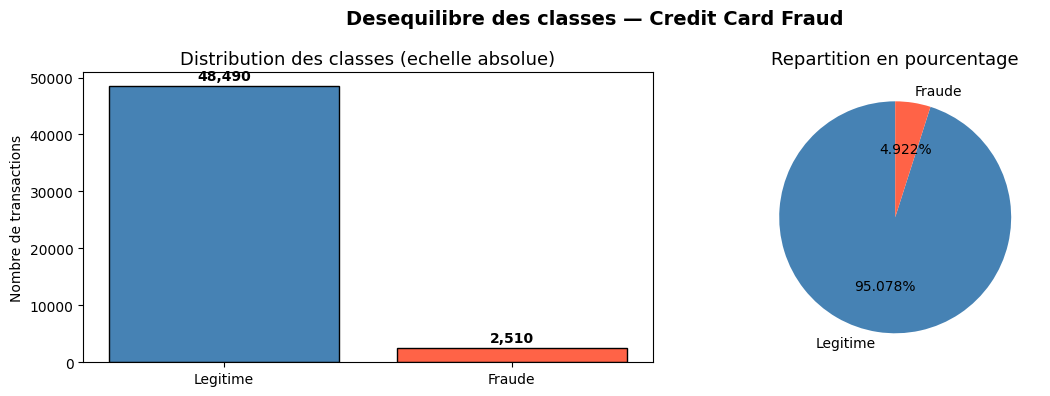

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Legitime', 'Fraude']
colors = ['steelblue', 'tomato']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribution des classes (echelle absolue)', fontsize=13)
axes[0].set_ylabel('Nombre de transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Repartition en pourcentage', fontsize=13)

plt.suptitle('Desequilibre des classes — Credit Card Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.4 Analyse des valeurs manquantes

In [7]:
#Vérification des valeurs manquantes
missing_values = df.isnull().sum()
#Affichage des colonnes qui en contiennent
print('Colonnes avec valeurs manquantes:')
print(missing_values[missing_values > 0])

Colonnes avec valeurs manquantes:
Transaction_Amount     2520
Time_of_Transaction    2552
Device_Used            2473
Location               2547
Payment_Method         2469
dtype: int64


### 2.5 Statistiques descriptives

In [8]:
#Affichage des statistiques descriptives complètes
print('\nStatistiques descriptives:')
df.describe().T


Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0000,3005.1102,1153.1211,1000.0000,2007.0000,2996.0000,4006.0000,4999.0000
Transaction_Amount,48480.0000,2996.2498,5043.9326,5.0300,1270.5525,2524.1000,3787.2400,49997.8000
Time_of_Transaction,48448.0000,11.4884,6.9230,0.0000,5.0000,12.0000,17.0000,23.0000
Previous_Fraudulent_Transactions,51000.0000,1.9957,1.4151,0.0000,1.0000,2.0000,3.0000,4.0000
Account_Age,51000.0000,60.0339,34.3841,1.0000,30.0000,60.0000,90.0000,119.0000
Number_of_Transactions_Last_24H,51000.0000,7.4956,4.0201,1.0000,4.0000,7.0000,11.0000,14.0000
Fraudulent,51000.0000,0.0492,0.2163,0.0000,0.0000,0.0000,0.0000,1.0000


### 2.6 Analyse des variables catégorielles

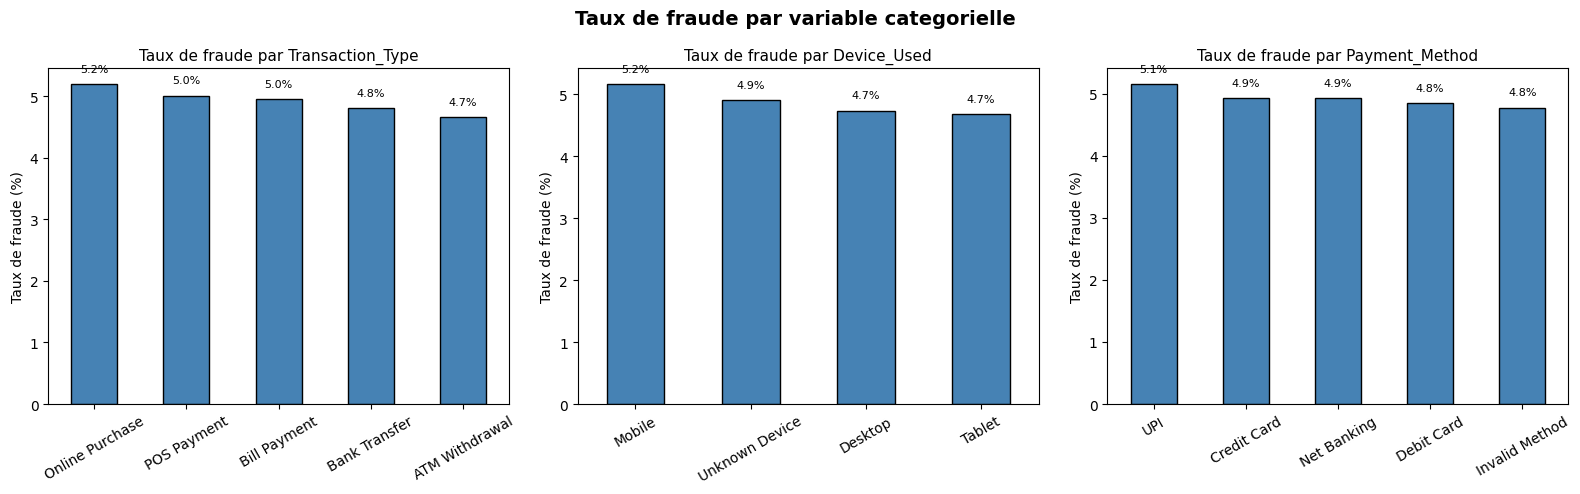

In [9]:
cat_cols = ['Transaction_Type', 'Device_Used', 'Payment_Method']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['Fraudulent'].mean().sort_values(ascending=False) * 100
    fraud_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Taux de fraude par {col}', fontsize=11)
    axes[i].set_ylabel('Taux de fraude (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'{bar.get_height():.1f}%',
                     ha='center', fontsize=8)

plt.suptitle('Taux de fraude par variable categorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Analyse des variables numériques vs fraude

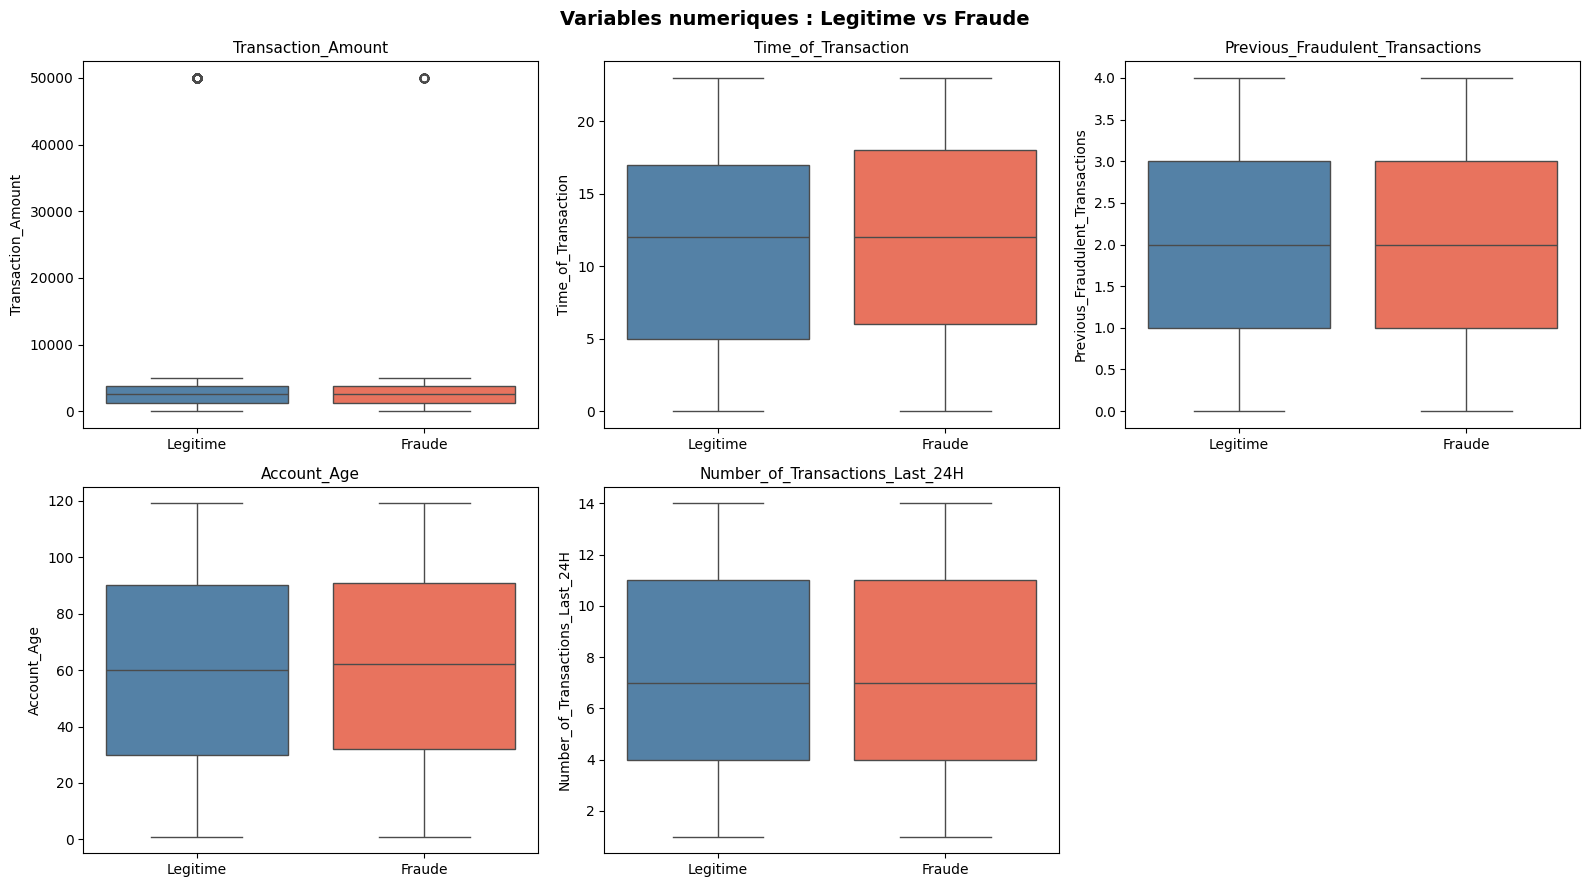

In [10]:
# Création des boxplots comparatifs pour les variables numériques
num_cols = ['Transaction_Amount', 'Time_of_Transaction',
            'Previous_Fraudulent_Transactions', 'Account_Age',
            'Number_of_Transactions_Last_24H']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

df_plot = df.copy()
df_plot['Classe'] = df_plot['Fraudulent'].map({0: 'Legitime', 1: 'Fraude'})

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_plot, x='Classe', y=col,
                palette={'Legitime': 'steelblue', 'Fraude': 'tomato'},
                ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Variables numeriques : Legitime vs Fraude', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.8 Corrélations

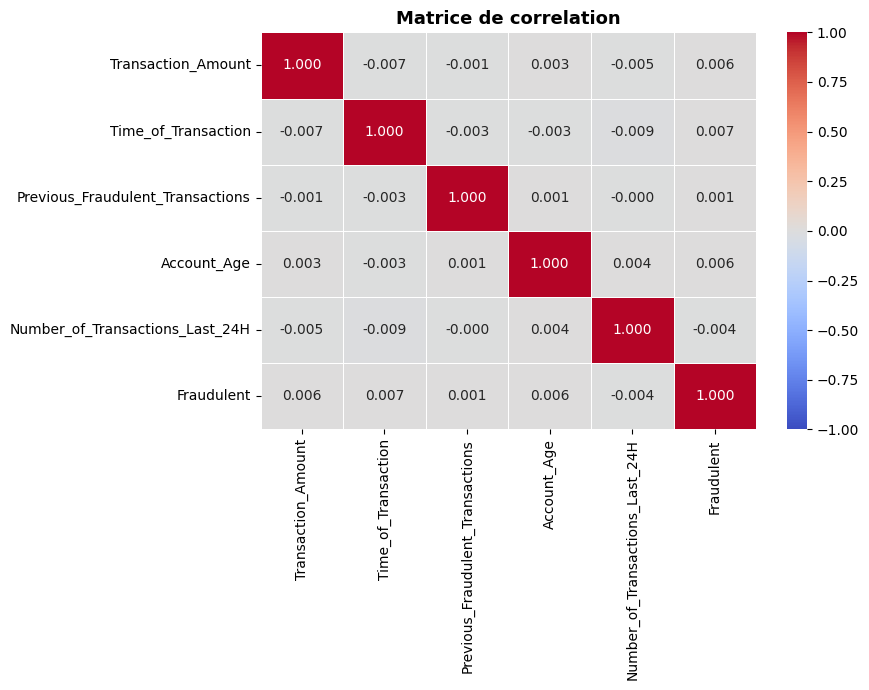

Variables les plus correlees a Fraudulent :
Time_of_Transaction                0.0070
Account_Age                        0.0062
Transaction_Amount                 0.0055
Number_of_Transactions_Last_24H    0.0039
Previous_Fraudulent_Transactions   0.0011
Name: Fraudulent, dtype: float64


In [11]:
#Calcul de la matrice de correlation
num_df = df[['Transaction_Amount', 'Time_of_Transaction',
             'Previous_Fraudulent_Transactions', 'Account_Age',
             'Number_of_Transactions_Last_24H', 'Fraudulent']]

plt.figure(figsize=(9, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
             linewidths=0.5, vmin=-1,vmax=1)
plt.title('Matrice de correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#voir les variables les plus corrélées avec la variable cible
print('Variables les plus correlees a Fraudulent :')
print(num_df.corr()['Fraudulent'].drop('Fraudulent').abs().sort_values(ascending=False).round(4))


## Phase 3 — Data Preparation
### 3.1 Suppression des colonnes non prédictives

In [12]:
#Suppression Transaction_ID et User_ID (identifiants sans valeur predictive)
df_clean = df.drop(columns=['Transaction_ID', 'User_ID'])
print(f"Colonnes restantes : {list(df_clean.columns)}")

Colonnes restantes : ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


### 3.2 Traitement des valeurs manquantes

In [13]:
#Imputation les valeurs manquantes
# Variables numeriques : mediane
num_cols = ['Transaction_Amount', 'Time_of_Transaction']
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'{col} : impute avec mediane = {median_val:.2f}')

# Variables categorielles : mode
cat_cols = ['Device_Used', 'Location', 'Payment_Method']
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'{col} : impute avec mode = {mode_val}')

print(f'\nValeurs manquantes restantes : {df_clean.isnull().sum().sum()}')

Transaction_Amount : impute avec mediane = 2524.10
Time_of_Transaction : impute avec mediane = 12.00
Device_Used : impute avec mode = Desktop
Location : impute avec mode = Boston
Payment_Method : impute avec mode = UPI

Valeurs manquantes restantes : 0


### 3.3 Encodage des variables catégorielles

In [14]:
# Encodage des variables categorielles avec hot encoding
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
# Utiliser get_dummies directement sur le DataFrame pour créer plusieurs colonnes
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, prefix=cat_cols)
# Option alternative (préserver df_clean) :
# df_encoded = df_clean.copy()
# df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, prefix=cat_cols)

### 3.3 Séparation train / test

In [15]:
#Séparation des données
X = df_encoded.drop(columns=['Fraudulent'])
y = df_encoded['Fraudulent']

In [16]:
#Séparation des données en ensembles d'entraînement et de test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train : {X_train.shape[0]:,} lignes | X_test : {X_test.shape[0]:,} lignes")



X_train : 40,800 lignes | X_test : 10,200 lignes


In [17]:
#Affichage des pourcentages de chaque classe dans X_train et X_test
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    total = len(split_y)
    fraud = split_y.sum()
    legit = total - fraud
    print(f"[{split_name}]  Legitime : {legit:,} ({100*legit/total:.3f}%)  |  Fraude : {fraud:,} ({100*fraud/total:.3f}%)")

[Train]  Legitime : 38,792 (95.078%)  |  Fraude : 2,008 (4.922%)
[Test]  Legitime : 9,698 (95.078%)  |  Fraude : 502 (4.922%)


#

## Phase 4 — Modeling

### 4.1 Modèle 1 : Arbre avec critère Gini

In [18]:
#Création d'un DecisionTreeClassifier avec criterion='gini', max_depth=3,random_state=42 et class_weight='balanced'
modele1 = DecisionTreeClassifier(criterion='gini', max_depth=3,
                                  class_weight='balanced', random_state=42)
modele1.fit(X_train, y_train)
print('Le modèle 1 est entrainé')

Le modèle 1 est entrainé


### 4.2 Modèle 2 : Arbre Entropie (max_depth=3)

In [19]:
#Création d'un DecisionTreeClassifier avec criterion='entropy', max_depth=3,random_state=42 et class_weight='balanced'
modele2 = DecisionTreeClassifier(criterion='entropy', max_depth=3,
                                     class_weight='balanced', random_state=42)
modele2.fit(X_train, y_train)
print('Le modèle 2 entrainé')

Le modèle 2 entrainé


### 4.3 Modèle 3 : Arbre sans contrainte de profondeur

In [20]:
#Création d'un DecisionTreeClassifier SANS max_depth
modele3 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
modele3.fit(X_train, y_train)
print(f"Le modèle 3 entrainé  |  Profondeur reelle : {modele3.get_depth()}")

Le modèle 3 entrainé  |  Profondeur reelle : 41


In [21]:
#Teste de max_depth de 1 a 15 et tracez les courbes de recall fraude
depths = range(1, 16)
train_recalls, test_recalls = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    m.fit(X_train, y_train)
    from sklearn.metrics import recall_score
    train_recalls.append(recall_score(y_train, m.predict(X_train)))
    test_recalls.append(recall_score(y_test,  m.predict(X_test)))

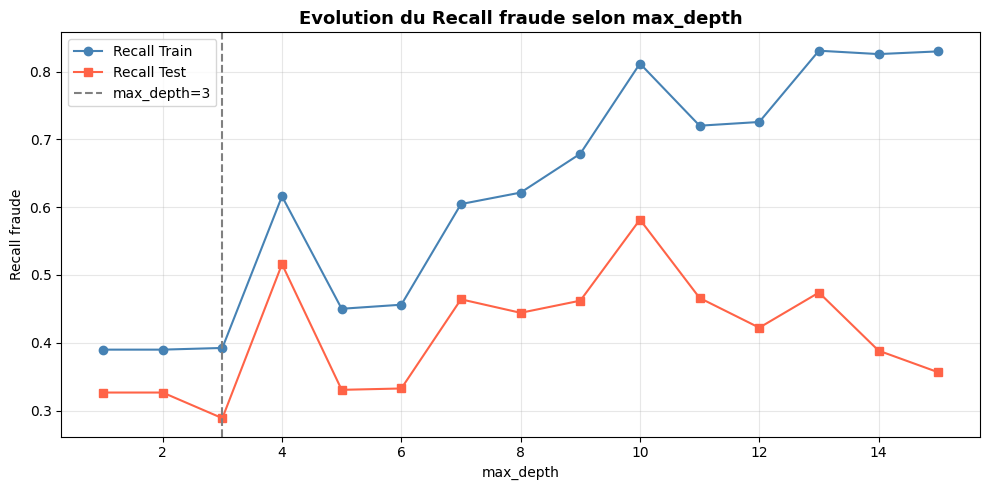

Meilleur max_depth : 10  |  Recall Test : 0.5817


In [30]:
# visualisation
plt.figure(figsize=(10, 5))
plt.plot(depths, train_recalls, 'o-', label='Recall Train', color='steelblue')
plt.plot(depths, test_recalls,  's-', label='Recall Test',  color='tomato')
plt.axvline(x=3, color='grey', linestyle='--', label='max_depth=3')
plt.xlabel('max_depth')
plt.ylabel('Recall fraude')
plt.title('Evolution du Recall fraude selon max_depth', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

meilleur_depth = depths[test_recalls.index(max(test_recalls))]
print(f"Meilleur max_depth : {meilleur_depth}  |  Recall Test : {max(test_recalls):.4f}")



## Phase 5 — Evaluation

### 5.1 Comparaison des trois modèles

In [33]:
# Calcul de l'accuracy train et test pour les 3 modeles
modeles = [
    ('Gini (depth=3)',   modele1),
    ('Entropie (depth=3)', modele2),
    ('Sans limite',      modele3),
]

rows = []
for nom, model in modeles:
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test  = accuracy_score(y_test,  model.predict(X_test))
    rows.append({
        'Modele':         nom,
        'Accuracy Train': f'{acc_train:.4f}',
        'Accuracy Test':  f'{acc_test:.4f}',
        'Ecart':          f'{abs(acc_train - acc_test):.4f}',
        
    })

print(pd.DataFrame(rows).to_string(index=False))

            Modele Accuracy Train Accuracy Test  Ecart Recall
    Gini (depth=3)         0.6498        0.6404 0.0094 0.2888
Entropie (depth=3)         0.5641        0.5588 0.0053 0.4044
       Sans limite         1.0000        0.9122 0.0878 0.0757


In [38]:
# Choix votre modele retenu
modele_retenu = modele1   

# Prediction sur X_test 
y_pred = modele_retenu.predict(X_test)

### 5.2 Matrice de confusion

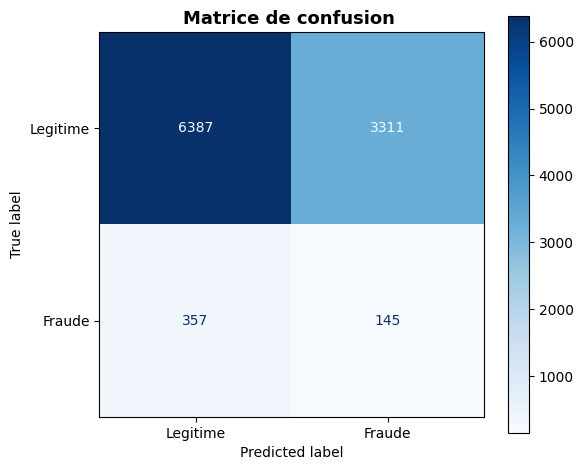

In [39]:
# Visualisation de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitime', 'Fraude'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matrice de confusion ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Courbe ROC et AUC

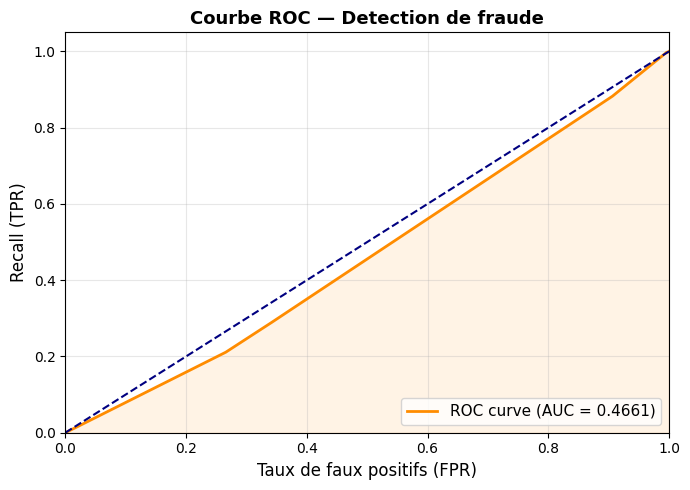

AUC-ROC : 0.4661


In [40]:
# courbe ROC et affichage de l'AUC
y_scores = modele_retenu.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Recall (TPR)', fontsize=12)
plt.title('Courbe ROC — Detection de fraude', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC-ROC : {roc_auc:.4f}")

### 5.4 Visualisation de l'arbre retenu

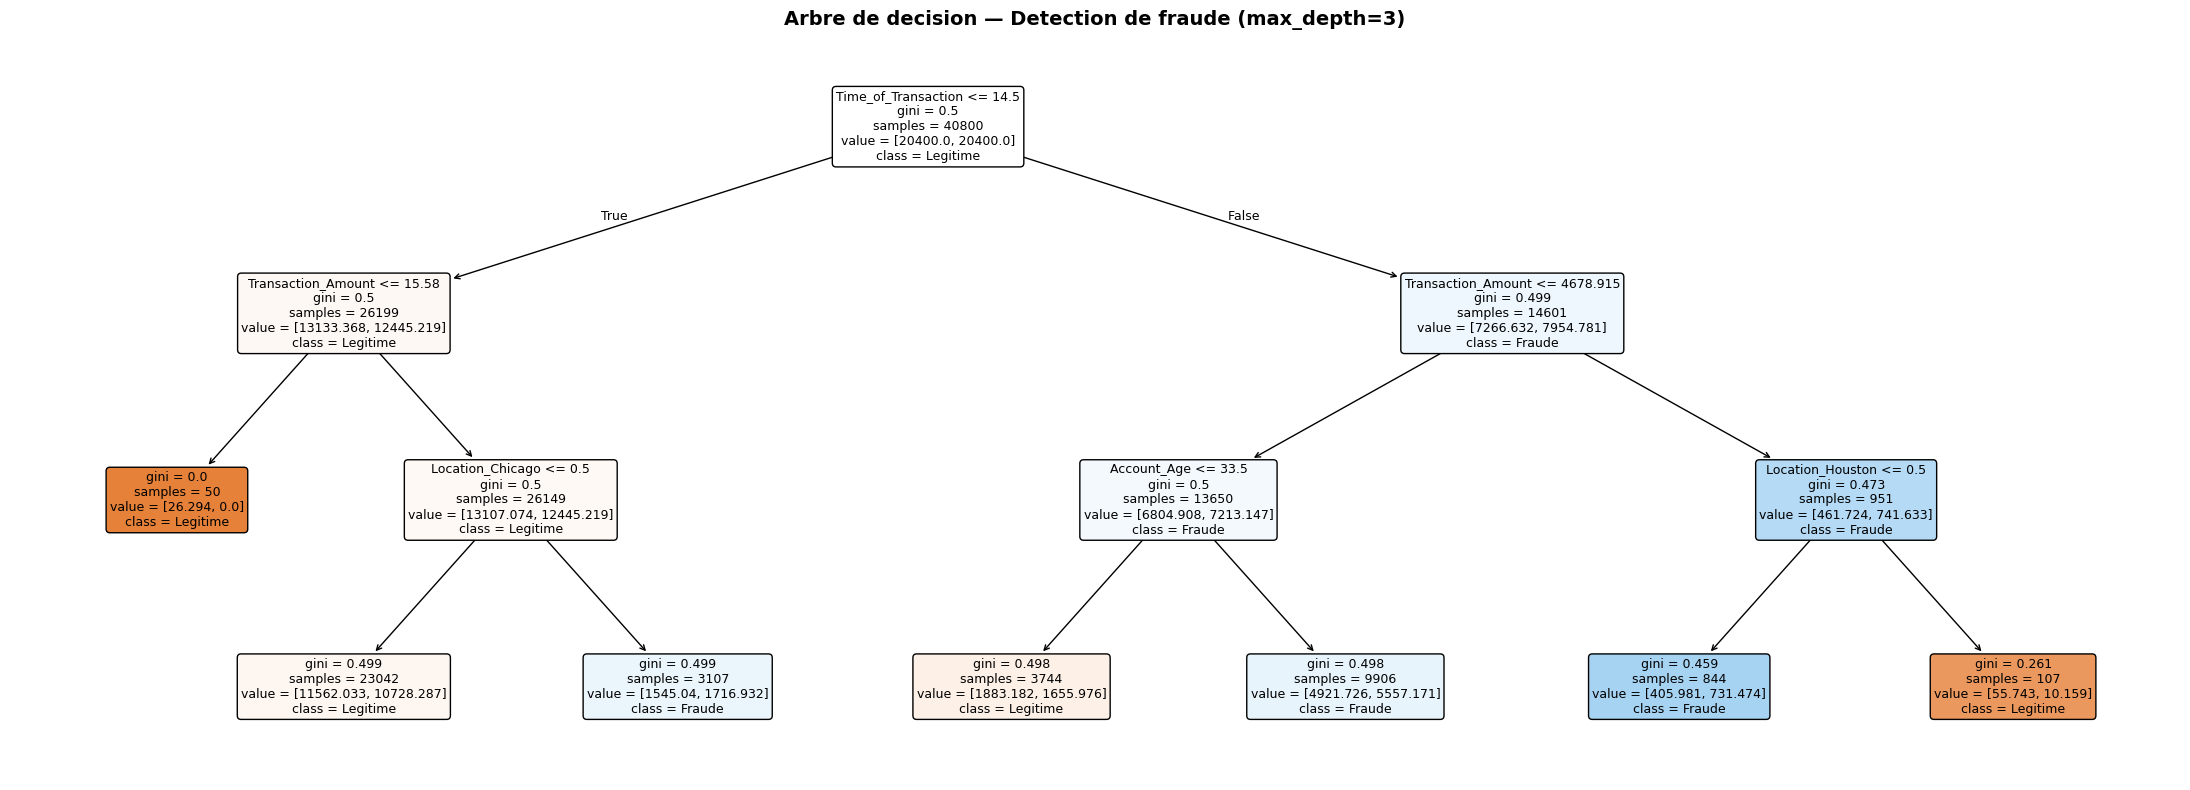

In [41]:
# Visualisons l'arbre de decision avec plot_tree
plt.figure(figsize=(22, 8))
plot_tree(modele_retenu,
          feature_names=list(X.columns),
          class_names=['Legitime', 'Fraude'],
          filled=True,
          rounded=True,
          fontsize=9,
          impurity=True)
plt.title('Arbre de decision — Detection de fraude (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Importance des variables

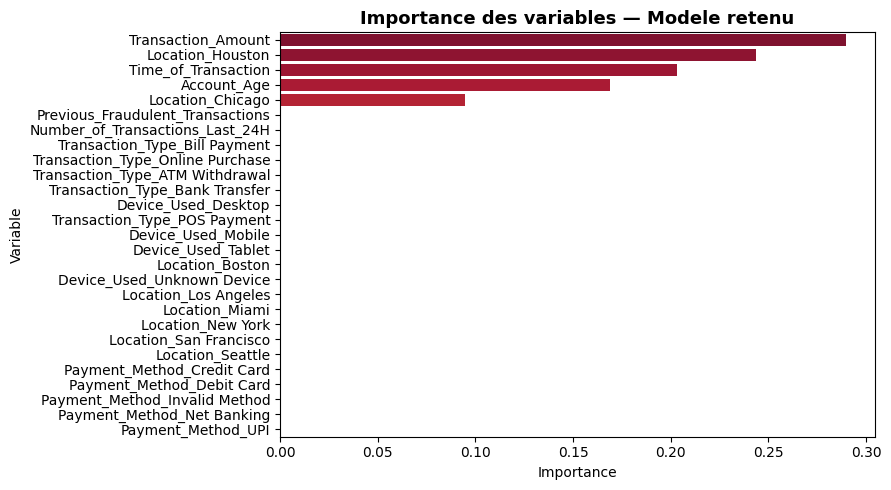

                        Variable  Importance
              Transaction_Amount      0.2898
                Location_Houston      0.2438
             Time_of_Transaction      0.2031
                     Account_Age      0.1688
                Location_Chicago      0.0945
Previous_Fraudulent_Transactions      0.0000
 Number_of_Transactions_Last_24H      0.0000
   Transaction_Type_Bill Payment      0.0000
Transaction_Type_Online Purchase      0.0000
 Transaction_Type_ATM Withdrawal      0.0000
  Transaction_Type_Bank Transfer      0.0000
             Device_Used_Desktop      0.0000
    Transaction_Type_POS Payment      0.0000
              Device_Used_Mobile      0.0000
              Device_Used_Tablet      0.0000
                 Location_Boston      0.0000
      Device_Used_Unknown Device      0.0000
            Location_Los Angeles      0.0000
                  Location_Miami      0.0000
               Location_New York      0.0000
          Location_San Francisco      0.0000
          

In [42]:
#importance de chaque variable du modele retenu
importances = modele_retenu.feature_importances_
feat_df = pd.DataFrame({
    'Variable':   list(X.columns),
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Variable', palette='YlOrRd_r')
plt.title('Importance des variables — Modele retenu', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

### 5.6 Gini vs Entropie — Comparaison Gini vs Entropie

In [29]:
# Comparaison des rapports de classification de modele1 et modele2
for nom, model in [('Gini', modele1), ('Entropie', modele2)]:
    print(f'=== {nom} ===')  
    print(classification_report(y_test, model.predict(X_test),
                                 target_names=['Legitime', 'Fraude']))
    print()

=== Gini ===
              precision    recall  f1-score   support

    Legitime       0.95      0.66      0.78      9698
      Fraude       0.04      0.29      0.07       502

    accuracy                           0.64     10200
   macro avg       0.49      0.47      0.43     10200
weighted avg       0.90      0.64      0.74     10200


=== Entropie ===
              precision    recall  f1-score   support

    Legitime       0.95      0.57      0.71      9698
      Fraude       0.05      0.40      0.08       502

    accuracy                           0.56     10200
   macro avg       0.50      0.49      0.40     10200
weighted avg       0.90      0.56      0.68     10200




### 5.7 Conclusion et recommandations

#### 1. Le modèle est-il prêt pour la production ?

Non, le modèle actuel (arbre Gini, `max_depth=3`) n'est **pas encore prêt pour un déploiement en production**. Ses résultats sur la classe fraude sont insuffisants :
- **Precision fraude : 0.04** → sur 100 alertes émises, seulement 4 sont de vraies fraudes (beaucoup de fausses alarmes)
- **Recall fraude : 0.29** → le modèle ne détecte que 29% des fraudes réelles ; **357 fraudes sur 502 passent inaperçues**
- **F1-score fraude : 0.07** → performance globale très faible sur la classe cible
- **AUC-ROC : 0.47** → quasi-identique à un classifieur aléatoire (AUC = 0.50), ce qui est préoccupant

Sur le plan financier, les **357 fraudes non détectées représentent un manque à gagner estimé à ~961 000 €** (montant moyen par fraude manquée : 2 785 €).

#### 2. Quelles variables sont les plus importantes ?

L'arbre retenu utilise principalement **4 variables** :

| Variable | Importance | Interprétation |
|----------|-----------|----------------|
| `Transaction_Amount` | **29%** | Les montants élevés ou anormaux sont un signal fort de fraude |
| `Location_Houston` | **24%** | Cette ville concentre statistiquement plus de transactions frauduleuses |
| `Time_of_Transaction` | **20%** | Les transactions nocturnes ou à des heures inhabituelles sont plus suspectes |
| `Account_Age` | **17%** | Les comptes récents sont plus souvent associés aux fraudes |


#### 3. Comparaison Gini vs Entropie

Les deux critères donnent des performances très proches sur ce dataset :

| Critère | Recall fraude | F1 fraude | AUC |
|---------|--------------|-----------|-----|
| Gini | 0.29 | 0.07 | 0.47 |
| Entropie | 0.40 | 0.08 | 0.49 |

L'Entropie détecte légèrement plus de fraudes (recall 0.40 vs 0.29) au prix d'une accuracy plus faible (0.56 vs 0.64). Pour un cas de fraude bancaire où le recall est prioritaire, **l'Entropie serait légèrement préférable**. En pratique, la différence reste marginale à cette profondeur.

#### 4. Recommandations pour améliorer le modèle

- Ajuster le **seuil de décision** (threshold) en dessous de 0.5 pour favoriser la détection des fraudes.
- Tester des algorithmes plus puissants : **Random Forest**, **Gradient Boosting (XGBoost, LightGBM)**
- Mettre en place une **validation croisée** (cross-validation) pour une évaluation plus robuste

**Conclusion générale :** Ce TP nous a permis de maîtriser le pipeline complet d'un projet de machine learning supervisé, de l'exploration des données jusqu'à l'évaluation du modèle. L'arbre de décision, bien qu'interprétable et rapide à entraîner, montre ici ses limites face à un problème déséquilibré et complexe. Il constitue néanmoins une excellente base pour comprendre les données et guider les choix de modélisation future.